 VRPTW — Clarke-Wright 


Ce notebook implémente l'heuristique **Clarke-Wright** sur les instances Solomon (.dzn)  
en respectant exactement le nombre de véhicules **K** utilisé dans MiniZinc,  
afin de permettre une **comparaison valide et équitable** des courbes de convergence.

**Instances traitées :** C101, R101, RC101 × {25, 50, 100} clients

In [12]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import copy
from itertools import combinations
from collections import defaultdict



1:parsing

In [ ]:
def parse_dzn(filepath):
    """Parse un fichier .dzn MiniZinc et retourne un dict avec tous les paramètres."""
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        raw = f.read()

    # Supprimer les commentaires
    text = re.sub(r'%.*', '', raw)
    # Supprimer les retours chariot Windows
    text = text.replace('\r', ' ')

    def get_int(name):
        m = re.search(rf'{name}\s*=\s*(\d+)', text)
        return int(m.group(1)) if m else None

    def get_array(name):
        m = re.search(rf'{name}\s*=\s*\[([^\]]+)\]', text, re.DOTALL)
        if not m:
            return None
        nums = re.findall(r'[-+]?\d+', m.group(1))
        return [int(x) for x in nums]

    def get_matrix(name, n):
        """Extrait la matrice dist de array2d(0..n, 0..n, [...])"""
        m = re.search(rf'{name}\s*=\s*array2d\s*\([^,]+,[^,]+,\s*\[([^\]]+)\]', text, re.DOTALL)
        if not m:
            return None
        nums = re.findall(r'[-+]?\d+', m.group(1))
        side = n + 1  # indices 0..n
        flat = [int(x) for x in nums]
        mat = np.array(flat).reshape(side, side)
        return mat  # mat[i,j] avec i,j dans 0..n

    n    = get_int('n')
    K    = get_int('K')
    cap  = get_int('cap')
    data = {
        'n':           n,
        'K':           K,
        'cap':         cap,
        'demand':      get_array('demand'),
        'early':       get_array('early'),
        'late':        get_array('late'),
        'service':     get_array('service'),
        'depot_early': get_int('depot_early'),
        'depot_late':  get_int('depot_late'),
        'dist':        get_matrix('dist', n),
    }
    return data


d = parse_dzn('RC101_25.dzn')
print(f"RC101_25 : n={d['n']}, K={d['K']}, cap={d['cap']}")
print(f"Demande totale : {sum(d['demand'])}")
print(f"Matrice dist shape : {d['dist'].shape}")

RC101_25 : n=25, K=4, cap=200
Demande totale : 540
Matrice dist shape : (26, 26)


2: Vérification de faisabilité d'une tournée

In [14]:
def route_cost(route, dist):
    """Distance totale d'une tournée (dépôt → clients → dépôt). Indices clients 1..n."""
    if not route:
        return 0
    cost = dist[0, route[0]]
    for a, b in zip(route[:-1], route[1:]):
        cost += dist[a, b]
    cost += dist[route[-1], 0]
    return cost

def is_feasible(route, data):
    """
    Vérifie capacité + fenêtres de temps pour une tournée.
    Les clients sont indexés 1..n dans les tableaux MiniZinc (demand, early, late, service).
    dist[0, i] = distance dépôt → client i.
    """
    if not route:
        return True

    demand  = data['demand']   # index 0..n-1 → client 1..n
    early   = data['early']
    late    = data['late']
    service = data['service']
    dist    = data['dist']
    cap     = data['cap']
    depot_early = data['depot_early']
    depot_late  = data['depot_late']

    # Capacité
    if sum(demand[c - 1] for c in route) > cap:
        return False

    # Fenêtres de temps
    t = depot_early
    prev = 0
    for c in route:
        t += dist[prev, c]
        if t > late[c - 1]:     # Arrivée trop tardive → infaisable
            return False
        t = max(t, early[c - 1])  # Attente si arrivée trop tôt
        t += service[c - 1]
        prev = c

    # Retour dépôt à temps
    t += dist[prev, 0]
    if t > depot_late:
        return False

    return True



## 3. Clarke-Wright avec suivi de convergence (style MiniZinc)

L'algorithme enregistre la **distance totale après chaque fusion** qui améliore la solution,  
exactement comme MiniZinc affiche ses solutions intermédiaires croissantes.

In [15]:
def clarke_wright_vrptw(data, max_vehicles=None, verbose=True):
    """
    Clarke-Wright Savings pour VRPTW.
    
    Paramètres
    ----------
    data         : dict issu de parse_dzn
    max_vehicles : int  → K de MiniZinc (contrainte sur le nb de véhicules)
    verbose      : affiche chaque amélioration (comme MiniZinc)
    
    Retourne
    --------
    routes         : liste des tournées finales
    history        : [(iteration, total_distance, nb_vehicles, timestamp)]
    total_distance : distance finale
    """
    n       = data['n']
    dist    = data['dist']
    cap     = data['cap']
    K_max   = max_vehicles if max_vehicles else n

    #  Étape 1 : Solution initiale — chaque client sur sa propre tournée 
    routes = [[c] for c in range(1, n + 1)]

    # Si déjà trop de véhicules... on affiche un warning mais on continue
    if verbose:
        init_dist = sum(route_cost(r, dist) for r in routes)
        print(f"  Solution initiale : {n} tournées, distance = {init_dist:.1f}")

    #  Étape 2 : Calcul des savings s(i,j) = d(0,i) + d(j,0) - d(i,j) 
    savings = []
    for i in range(1, n + 1):
        for j in range(1, n + 1):
            if i != j:
                s = dist[0, i] + dist[j, 0] - dist[i, j]
                savings.append((s, i, j))
    savings.sort(key=lambda x: -x[0])  # Trier par saving décroissant

    # Étape 3 : Structures pour les fusions 
    # route_of[c] = index dans routes[]
    route_of = {c: c - 1 for c in range(1, n + 1)}

    history = []
    iteration = 0
    t_start = time.time()

    def total_dist():
        return sum(route_cost(r, dist) for r in routes if r)

    # Enregistrer la solution initiale
    init_d = total_dist()
    history.append((0, init_d, len([r for r in routes if r]), 0.0))

    best_dist = init_d

    # Étape 4 : Fusions 
    for s, i, j in savings:
        ri_idx = route_of[i]
        rj_idx = route_of[j]

        # Pas la même tournée
        if ri_idx == rj_idx:
            continue

        ri = routes[ri_idx]
        rj = routes[rj_idx]

        if not ri or not rj:
            continue

        # i doit être en fin de ri, j doit être en début de rj
        if ri[-1] != i or rj[0] != j:
            continue

        # Candidat à la fusion
        merged = ri + rj

        # Vérifier faisabilité
        if not is_feasible(merged, data):
            continue

        # Vérifier contrainte K véhicules
        active_routes = [r for r in routes if r]
        if len(active_routes) - 1 < 1:  # On ne peut pas descendre en dessous de 1
            continue
        # Après fusion : nb_routes - 1 (on remplace ri et rj par merged)
        nb_after = len(active_routes) - 1
        # On autorise toujours la fusion si nb_after >= 1
        # La contrainte K_max : on force à garder au moins 1 tournée
        # mais on n'empêche PAS la fusion si elle réduit en dessous de K_max
        # (Clarke-Wright cherche à minimiser la distance, K_max est un budget max)

        # Effectuer la fusion
        routes[ri_idx] = merged
        routes[rj_idx] = []

        # Mettre à jour route_of
        for c in rj:
            route_of[c] = ri_idx

        iteration += 1
        new_dist = total_dist()
        elapsed  = time.time() - t_start
        nb_active = len([r for r in routes if r])

        if new_dist < best_dist:
            best_dist = new_dist
            history.append((iteration, new_dist, nb_active, elapsed))
            if verbose:
                print(f"  Iter {iteration:4d} | Dist = {new_dist:8.1f} "
                      f"| Véhicules = {nb_active:3d} | t = {elapsed:.3f}s")

    #  Résultat final 
    final_routes = [r for r in routes if r]
    final_dist   = total_dist()
    elapsed_total = time.time() - t_start

    # Ajouter dernier point si pas encore enregistré
    if not history or history[-1][1] != final_dist:
        history.append((iteration, final_dist, len(final_routes), elapsed_total))

    if verbose:
        print(f"\n  ✔ Solution finale : {len(final_routes)} véhicules, "
              f"distance = {final_dist:.1f}, temps = {elapsed_total:.3f}s")
        if len(final_routes) > K_max:
            print(f"  ⚠ Attention : {len(final_routes)} véhicules > K_max={K_max} "
                  f"(contrainte de fenêtres de temps trop restrictive)")
        elif len(final_routes) <= K_max:
            print(f"  ✓ Contrainte K = {K_max} respectée ({len(final_routes)} ≤ {K_max})")

    return final_routes, history, final_dist



4: Résolution de toutes les instances

Adapte le chemin vers les fichiers .dzn si nécessaire.


In [18]:
import os

#  Chemin vers les fichiers .dzn 
DZN_DIR = '.'   

instances = [
    'C101_25', 'C101_50', 'C101_100',
    'R101_25', 'R101_50', 'R101_100',
    'RC101_25','RC101_50','RC101_100',
]

results   = {}  # instance → (routes, history, final_dist, K_minizinc)
all_data  = {}  # instance → data dict

for inst in instances:
    path = os.path.join(DZN_DIR, f'{inst}.dzn')
    if not os.path.exists(path):
        print(f'[MANQUANT] {path}')
        continue

    
    print(f'  Instance : {inst}')
    
    data = parse_dzn(path)
    all_data[inst] = data
    K_mzn = data['K']
    print(f"  n={data['n']}, K_MiniZinc={K_mzn}, cap={data['cap']}")

    routes, history, final_dist = clarke_wright_vrptw(
        data, max_vehicles=K_mzn, verbose=True
    )
    results[inst] = (routes, history, final_dist, K_mzn)




  Instance : C101_25
  n=25, K_MiniZinc=3, cap=200
  Solution initiale : 25 tournées, distance = 1130.0
  Iter    1 | Dist =   1053.0 | Véhicules =  24 | t = 0.000s
  Iter    2 | Dist =    979.0 | Véhicules =  23 | t = 0.000s
  Iter    3 | Dist =    907.0 | Véhicules =  22 | t = 0.000s
  Iter    4 | Dist =    838.0 | Véhicules =  21 | t = 0.000s
  Iter    5 | Dist =    773.0 | Véhicules =  20 | t = 0.001s
  Iter    6 | Dist =    711.0 | Véhicules =  19 | t = 0.001s
  Iter    7 | Dist =    673.0 | Véhicules =  18 | t = 0.001s
  Iter    8 | Dist =    636.0 | Véhicules =  17 | t = 0.001s
  Iter    9 | Dist =    599.0 | Véhicules =  16 | t = 0.001s
  Iter   10 | Dist =    562.0 | Véhicules =  15 | t = 0.001s
  Iter   11 | Dist =    527.0 | Véhicules =  14 | t = 0.001s
  Iter   12 | Dist =    492.0 | Véhicules =  13 | t = 0.001s
  Iter   13 | Dist =    461.0 | Véhicules =  12 | t = 0.001s
  Iter   14 | Dist =    430.0 | Véhicules =  11 | t = 0.001s
  Iter   15 | Dist =    400.0 | Véhicules 

5: Tableau récapitulatif 

In [19]:
print(f"{'Instance':<12} {'n':>4} {'K_MZN':>6} {'K_CW':>5} {'Dist_CW':>10} {'Iter':>6} {'Temps(s)':>9}")
print('-' * 58)

for inst in instances:
    if inst not in results:
        continue
    routes, history, final_dist, K_mzn = results[inst]
    data = all_data[inst]
    n_iters = history[-1][0]
    t_total = history[-1][3]
    k_cw    = len(routes)
    print(f"{inst:<12} {data['n']:>4} {K_mzn:>6} {k_cw:>5} {final_dist:>10.1f} {n_iters:>6} {t_total:>9.3f}")

Instance        n  K_MZN  K_CW    Dist_CW   Iter  Temps(s)
----------------------------------------------------------
C101_25        25      3     4      261.0     21     0.002
C101_50        50     25     7      466.0     43     0.005
C101_100      100     25    12      930.0     88     0.054
R101_25        25      8     9      634.0     16     0.004
R101_50        50     25    15     1126.0     35     0.026
R101_100      100     25    32     2000.0     68     0.042
RC101_25       25      4     9      722.0     16     0.001
RC101_50       50     25    14     1224.0     36     0.004
RC101_100     100     25    24     2012.0     76     0.023


6: Courbes de convergence — par famille d'instances

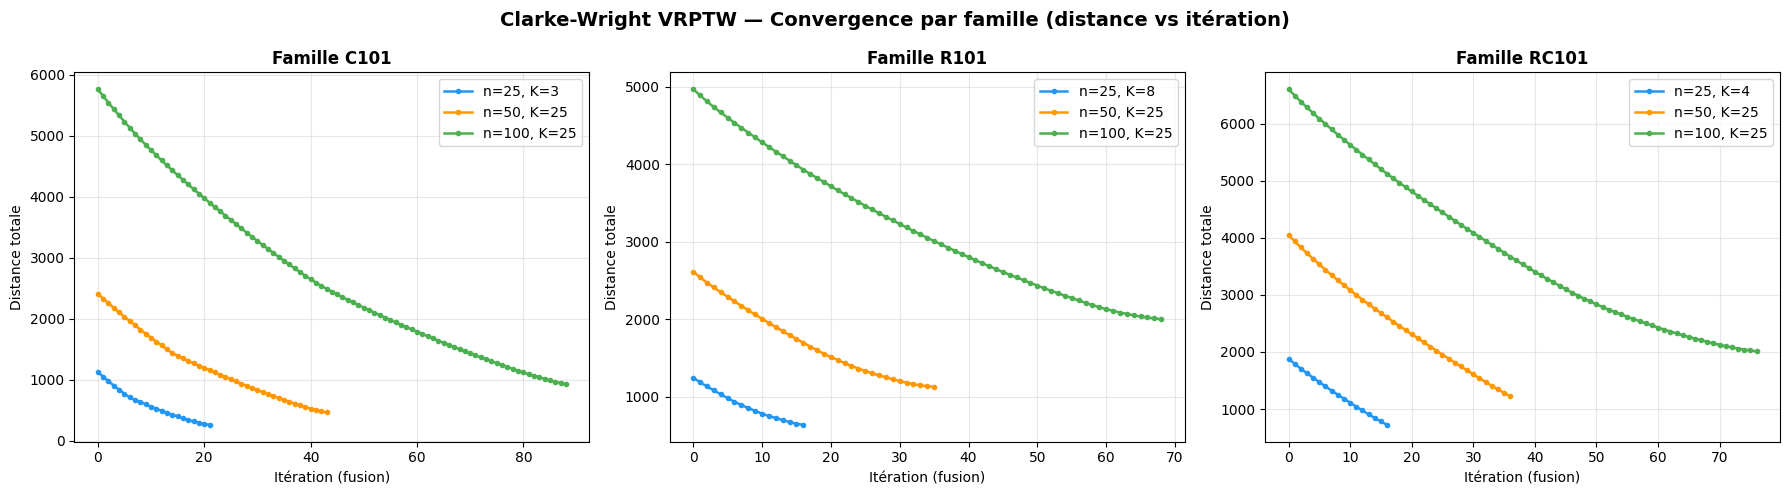

Figure sauvegardée : convergence_CW_families.png


In [7]:
families = {
    'C101': ['C101_25', 'C101_50', 'C101_100'],
    'R101': ['R101_25', 'R101_50', 'R101_100'],
    'RC101':['RC101_25','RC101_50','RC101_100'],
}

colors = {'25': '#2196F3', '50': '#FF9800', '100': '#4CAF50'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Clarke-Wright VRPTW — Convergence par famille (distance vs itération)',
             fontsize=14, fontweight='bold')

for ax, (family, inst_list) in zip(axes, families.items()):
    for inst in inst_list:
        if inst not in results:
            continue
        _, history, _, K_mzn = results[inst]
        size = inst.split('_')[1]
        iters = [h[0] for h in history]
        dists = [h[1] for h in history]
        ax.plot(iters, dists, marker='o', markersize=3,
                color=colors[size], linewidth=1.8,
                label=f'n={size}, K={K_mzn}')

    ax.set_title(f'Famille {family}', fontweight='bold')
    ax.set_xlabel('Itération (fusion)')
    ax.set_ylabel('Distance totale')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_CW_families.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : convergence_CW_families.png')

7: Courbes de convergence — par taille (pour comparaison directe avec LNS)

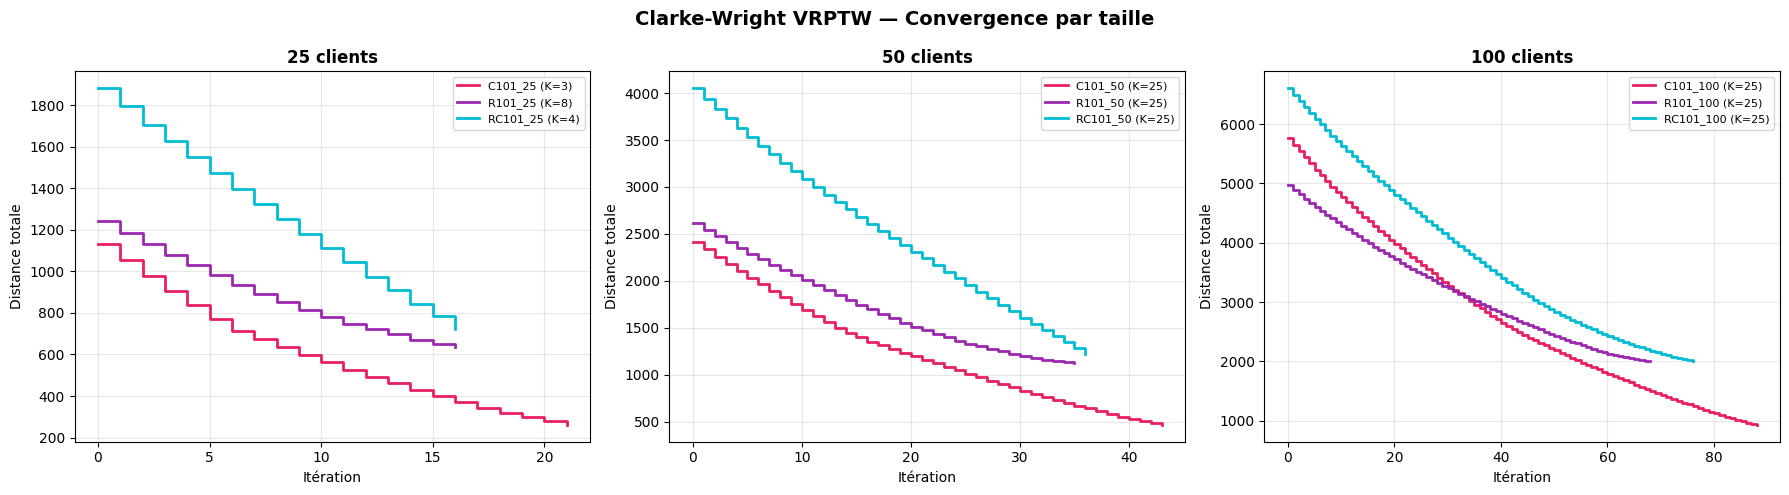

Figure sauvegardée : convergence_CW_sizes.png


In [8]:
sizes = {
    '25 clients':  ['C101_25', 'R101_25', 'RC101_25'],
    '50 clients':  ['C101_50', 'R101_50', 'RC101_50'],
    '100 clients': ['C101_100','R101_100','RC101_100'],
}

fam_colors = {'C101': '#E91E63', 'R101': '#9C27B0', 'RC101': '#00BCD4'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Clarke-Wright VRPTW — Convergence par taille',
             fontsize=14, fontweight='bold')

for ax, (size_label, inst_list) in zip(axes, sizes.items()):
    for inst in inst_list:
        if inst not in results:
            continue
        _, history, _, K_mzn = results[inst]
        fam = '_'.join(inst.split('_')[:1])  # 'C101', 'R101', 'RC101'
        iters = [h[0] for h in history]
        dists = [h[1] for h in history]
        # Normaliser par la distance initiale pour comparer les pentes
        ax.step(iters, dists, where='post',
                color=fam_colors.get(inst.rsplit('_',1)[0], 'gray'),
                linewidth=2, label=f'{inst} (K={K_mzn})')

    ax.set_title(size_label, fontweight='bold')
    ax.set_xlabel('Itération')
    ax.set_ylabel('Distance totale')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_CW_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : convergence_CW_sizes.png')

## 8. Visualisation des tournées

C:\Users\ayaak\AppData\Local\Temp\ipykernel_2632\3493675663.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(routes_final))


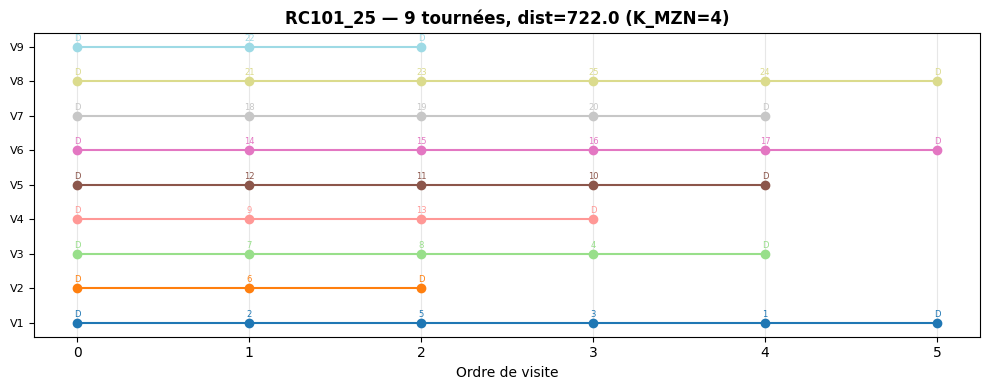

C:\Users\ayaak\AppData\Local\Temp\ipykernel_2632\3493675663.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(routes_final))


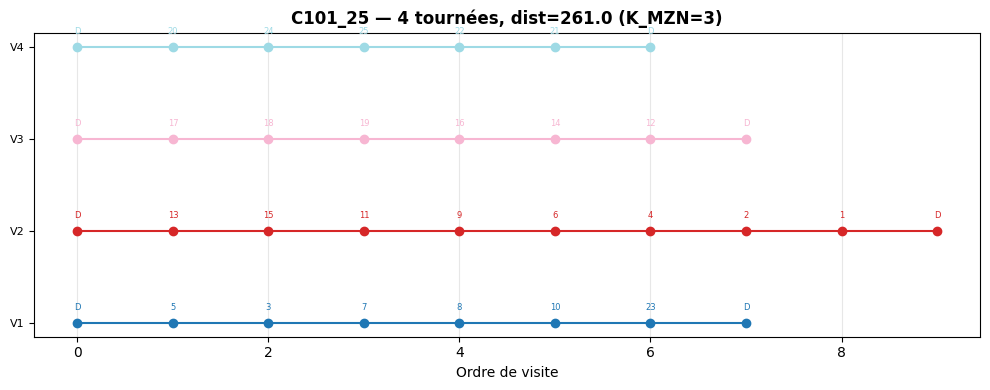

C:\Users\ayaak\AppData\Local\Temp\ipykernel_2632\3493675663.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(routes_final))


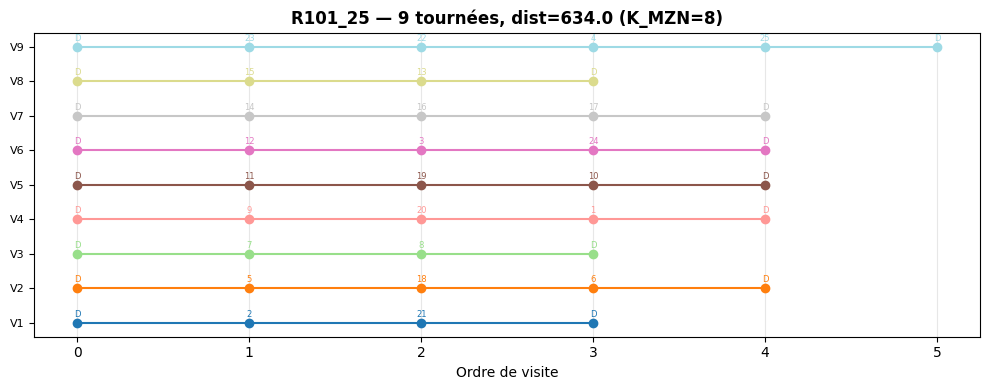

In [9]:
def plot_routes(inst_name, data=None, routes=None, ax=None):
    """
    Dessine les tournées Clarke-Wright.
    Note : les fichiers .dzn ne contiennent pas les coordonnées x,y,
    on affiche donc les tournées comme des listes ordonnées de clients.
    """
    if inst_name not in results:
        print(f'{inst_name} non disponible.')
        return

    routes_final, _, dist_final, K_mzn = results[inst_name]

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 4))

    cmap = plt.cm.get_cmap('tab20', len(routes_final))

    for k, route in enumerate(routes_final):
        # Représentation linéaire : position = rang dans la tournée
        x = list(range(len(route) + 2))
        y = [k] * (len(route) + 2)
        labels = ['D'] + [str(c) for c in route] + ['D']
        ax.plot(x, y, '-o', color=cmap(k), markersize=6, linewidth=1.5)
        for xi, yi, lbl in zip(x, y, labels):
            ax.text(xi, yi + 0.12, lbl, ha='center', va='bottom',
                    fontsize=6, color=cmap(k))

    ax.set_yticks(range(len(routes_final)))
    ax.set_yticklabels([f'V{k+1}' for k in range(len(routes_final))], fontsize=8)
    ax.set_xlabel('Ordre de visite')
    ax.set_title(f'{inst_name} — {len(routes_final)} tournées, dist={dist_final:.1f} (K_MZN={K_mzn})',
                 fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)

    if own_fig:
        plt.tight_layout()
        plt.savefig(f'routes_{inst_name}.png', dpi=120, bbox_inches='tight')
        plt.show()

# Exemples
for inst in ['RC101_25', 'C101_25', 'R101_25']:
    if inst in results:
        plot_routes(inst)

In [10]:
import csv
import os

os.makedirs('cw_convergence_data', exist_ok=True)

for inst in instances:
    if inst not in results:
        continue
    _, history, _, _ = results[inst]
    csv_path = f'cw_convergence_data/{inst}_CW.csv'
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['iteration', 'distance', 'nb_vehicles', 'time_s'])
        for row in history:
            writer.writerow(row)
    print(f'Exporté : {csv_path}')

print('\nTous les CSVs générés dans le dossier cw_convergence_data/')

Exporté : cw_convergence_data/C101_25_CW.csv
Exporté : cw_convergence_data/C101_50_CW.csv
Exporté : cw_convergence_data/C101_100_CW.csv
Exporté : cw_convergence_data/R101_25_CW.csv
Exporté : cw_convergence_data/R101_50_CW.csv
Exporté : cw_convergence_data/R101_100_CW.csv
Exporté : cw_convergence_data/RC101_25_CW.csv
Exporté : cw_convergence_data/RC101_50_CW.csv
Exporté : cw_convergence_data/RC101_100_CW.csv

Tous les CSVs générés dans le dossier cw_convergence_data/


## 10. Détail des tournées finales

In [20]:
def print_solution(inst_name):
    if inst_name not in results:
        print(f'{inst_name} non résolu.')
        return
    routes, history, final_dist, K_mzn = results[inst_name]
    data = all_data[inst_name]
    dist = data['dist']

    print(f'\n . {inst_name} .')
    print(f'  K_MiniZinc = {K_mzn}  |  Véhicules CW utilisés = {len(routes)}')
    print(f'  Distance totale = {final_dist:.1f}')
    print()
    for k, route in enumerate(routes):
        cap_used = sum(data['demand'][c-1] for c in route)
        dist_r   = route_cost(route, dist)
        print(f'  V{k+1:02d}: Dépôt → {" → ".join(str(c) for c in route)} → Dépôt')
        print(f'       charge={cap_used}/{data["cap"]}  dist={dist_r:.1f}')

# Afficher le détail pour les instances 25 clients
for inst in ['C101_25', 'R101_25', 'RC101_25']:
    print_solution(inst)


 . C101_25 .
  K_MiniZinc = 3  |  Véhicules CW utilisés = 4
  Distance totale = 261.0

  V01: Dépôt → 5 → 3 → 7 → 8 → 10 → 23 → Dépôt
       charge=80/200  dist=51.0
  V02: Dépôt → 13 → 15 → 11 → 9 → 6 → 4 → 2 → 1 → Dépôt
       charge=160/200  dist=87.0
  V03: Dépôt → 17 → 18 → 19 → 16 → 14 → 12 → Dépôt
       charge=120/200  dist=91.0
  V04: Dépôt → 20 → 24 → 25 → 22 → 21 → Dépôt
       charge=100/200  dist=32.0

 . R101_25 .
  K_MiniZinc = 8  |  Véhicules CW utilisés = 9
  Distance totale = 634.0

  V01: Dépôt → 2 → 21 → Dépôt
       charge=18/200  dist=46.0
  V02: Dépôt → 5 → 18 → 6 → Dépôt
       charge=41/200  dist=54.0
  V03: Dépôt → 7 → 8 → Dépôt
       charge=14/200  dist=59.0
  V04: Dépôt → 9 → 20 → 1 → Dépôt
       charge=35/200  dist=74.0
  V05: Dépôt → 11 → 19 → 10 → Dépôt
       charge=45/200  dist=81.0
  V06: Dépôt → 12 → 3 → 24 → Dépôt
       charge=35/200  dist=70.0
  V07: Dépôt → 14 → 16 → 17 → Dépôt
       charge=41/200  dist=84.0
  V08: Dépôt → 15 → 13 → Dépôt
    